# Regression Task on Spotify Dataset

## 0 Imports

In [25]:
# Standard Libraries
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from importlib import reload
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
# Config Files and Python Modules
from config import *

In [2]:
import config
#reload config module
reload(config)
from config import *

In [ ]:
# execute everything?
exAll = False

## 1 Load and Explore Dataset

Link to dataset: https://www.kaggle.com/datasets/rudraprasadbhuyan/spotify-dataset-for-ml-practice

The **Spotify Dataset for ML Practice** is a curated machine-learning resource from Kaggle designed to support exploration, experimentation, and model development. The original dataset contained **24 features**, while the engineered version expands this to **158 features** with roughly **114,000 tracks** included.

- **Original shape:** 114,000 rows × 24 columns  
- **Engineered shape:** 113,999 rows × 158 columns  
- **Recorded tracks:** ~114,000 Spotify songs  

The dataset publisher applied extensive preprocessing and feature engineering, including:

1. **Column Removal:** Dropped *index*, *album_name*, *track_name*, *duration_ms*, *duration_min*, *key*, *artists*, and *track_id* to eliminate identifiers and redundant fields.  
2. **Type Conversion:** Converted the *explicit* column from boolean to integer for better model compatibility.  
3. **Feature Combination:** Merged *key* and *mode* into a composite integer feature (*key_mode*) representing musical structure.  
4. **One-Hot Encoding:** Expanded *track_genre* into 114 binary genre indicator columns.  
5. **Label Encoding:** Added *track_genre_le* for experiments involving multiclass classification.  
6. **Custom Feature Engineering:** Created numerous derived metrics (e.g., *loudness_intensity*, *mood_pca*) to provide richer inputs for modelling.  
7. **Clustering:** Generated acoustic–mood clusters to support unsupervised and semi-supervised learning tasks.  

The aim of this notebook is to perform **regression on the `popularity` column** using the provided engineered features.  
Extensive additional feature engineering is **not** in scope; instead, the focus is on comparing the performance of our **custom Regression Tree** and **custom Random Forest** implementations against standard sklearn regressors.


### 1.1 Load Raw Data

In [3]:
# Download latest version
if ("modified-spotify-dataset.csv" not in os.listdir("../data")):
    print("Downloading Spotify Dataset from Kaggle...")
    # Download latest version
    path = kagglehub.dataset_download("rudraprasadbhuyan/spotify-dataset-for-ml-practice", path="modified-spotify-dataset.csv")
    #move to data folder
    os.replace(path, "../data/modified-spotify-dataset.csv")
    # Load Data
print("Reading Spotify Dataset...")
data = pd.read_csv("../data/modified-spotify-dataset.csv")
data.head()

Reading Spotify Dataset...


,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,...,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,track_genre,track_genre_le
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.577830,0.186048,1.0,0.132593,0.0,0.0,-1.141849,acoustic,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.250904,-0.942392,1.0,-1.658038,0.0,0.0,-1.489701,acoustic,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.507132,-0.057979,1.0,-0.538749,0.0,0.0,-1.528296,acoustic,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.473744,-0.173222,1.0,-1.803951,0.0,0.0,1.987849,acoustic,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500000,1.461916,-0.214050,1.0,-0.528464,0.0,0.0,-0.073343,acoustic,0.0


### 1.2 Initial Data Overview

In [ ]:
data.drop(columns=["track_genre"], inplace=True)
data.drop(columns=["track_genre_le"], inplace=True)
data.drop(columns=["popularity_level"], inplace=True)
target = "popularity"
one_hot_genre_columns = [col for col in data.columns if "track_genre_" in col]
one_hot_duration_columns = [col for col in data.columns if "duration_" in col and "duration_log" not in col]

one_hot_columns = one_hot_genre_columns + one_hot_duration_columns
binary_columns = [col for col in data.columns if data[col].nunique() == 2 and col not in one_hot_columns]
numeric_columns = [col for col in data.columns if col not in one_hot_columns + binary_columns + [target]]

print(f"""The dataset has {data.shape[0]} rows and {data.shape[1]} columns.
Track genre was one-hot encoded into {len(one_hot_genre_columns)} columns.
Duration was encoded in {len(one_hot_duration_columns)} columns.
There are {len(binary_columns)} binary columns in the dataset.
There are {len(numeric_columns)} numeric columns in the dataset.
There are {len(one_hot_columns) + len(binary_columns) + len(numeric_columns)} total feature columns in the dataset.
The target column is '{target}'.
""")

The dataset has 113999 rows and 157 columns.
Track genre was one-hot encoded into 114 columns.
Duration was encoded in 5 columns.
There are 5 binary columns in the dataset.
There are 32 numeric columns in the dataset.
There are 156 total feature columns in the dataset.
The target column is 'popularity'.



In [5]:
print(f"{'Column':35} {'Dtype':10} {'Unique':>8} {'Min':>15} {'Max':>15}")
print("-" * 85)
# print target column info
print(f"{target:35} {data[target].dtype} {data[target].nunique():8} {data[target].min():15} {data[target].max():15}")
for col in binary_columns:
    print(f"{col:35} {data[col].dtype} {data[col].nunique():8} {data[col].min():15} {data[col].max():15}")
for col in numeric_columns:
    print(f"{col:35} {data[col].dtype} {data[col].nunique():8} {data[col].min():15} {data[col].max():15}")
for col in one_hot_columns:
    print(f"{col:35} {data[col].dtype} {data[col].nunique():8} {data[col].min():15} {data[col].max():15}")

Column                              Dtype        Unique             Min             Max
-------------------------------------------------------------------------------------
popularity                          float64      101 -1.4902054888413832 2.993122109473847
explicit                            float64        2             0.0             1.0
mode                                float64        2             0.0             1.0
time_signature_class_boolean        float64        2             0.0             1.0
is_instrumental                     float64        2             0.0             1.0
is_dance_hit                        float64        2             0.0             1.0
loudness_level                      float64        5             0.0             4.0
popularity_level                    float64        5             0.0             4.0
tempo_class                         float64        5             0.0             4.0
time_signature                      float64        5 -9

In [23]:
data['popularity_level'].unique()

array([0., 2., 4., 3., 1.])

### 1.3 Exploratory Data Analysis if interesting

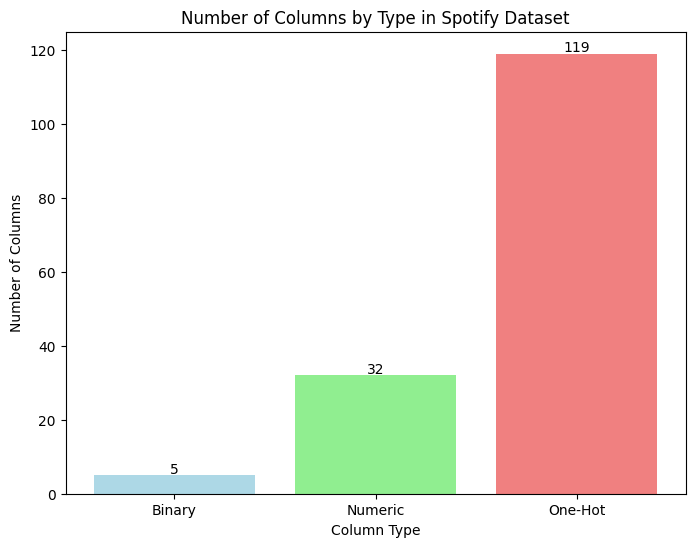

In [6]:
#barcharts on how many binary, numeric, one-hot columns there are
import matplotlib.pyplot as plt
labels = ['Binary', 'Numeric', 'One-Hot']
sizes = [len(binary_columns), len(numeric_columns), len(one_hot_columns)]
colors = ['lightblue', 'lightgreen', 'lightcoral']
plt.figure(figsize=(8, 6))
plt.bar(labels, sizes, color=colors)
plt.title('Number of Columns by Type in Spotify Dataset')
plt.xlabel('Column Type')
plt.ylabel('Number of Columns')
for i, size in enumerate(sizes):
    plt.text(i, size + 0.5, str(size), ha='center')
plt.show()

In [7]:
display(data[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
loudness_level,113999.0,1.999912e+00,1.414251,0.000000,1.000000,2.000000e+00,3.000000,4.000000
popularity_level,113999.0,1.715480e+00,1.044655,0.000000,1.000000,1.000000e+00,3.000000,4.000000
tempo_class,113999.0,1.038816e+00,0.315915,0.000000,1.000000,1.000000e+00,1.000000,4.000000
time_signature,113999.0,-2.273757e-16,1.000004,-9.024149,0.221824,2.218242e-01,0.221824,2.533318
key_mode,113999.0,7.878368e-17,1.000004,-1.511882,-0.920961,-7.678645e-02,0.767388,1.611562
artist_song_count,113999.0,3.590142e-17,1.000004,-0.575306,-0.551262,-3.829536e-01,0.049840,6.108944
album_freq,113999.0,-3.191237e-17,1.000004,-0.514901,-0.472292,-3.870751e-01,-0.088815,7.751164
danceability,113999.0,-1.116933e-16,1.000004,-3.266071,-0.638466,7.605855e-02,0.738722,2.409787
loudness,113999.0,2.114195e-16,1.000004,-8.206263,-0.348764,2.495260e-01,0.647392,2.543268
speechiness,113999.0,3.191237e-17,1.000004,-0.800628,-0.461092,-3.381399e-01,-0.001441,8.326191


#### 1.3.1 Histograms

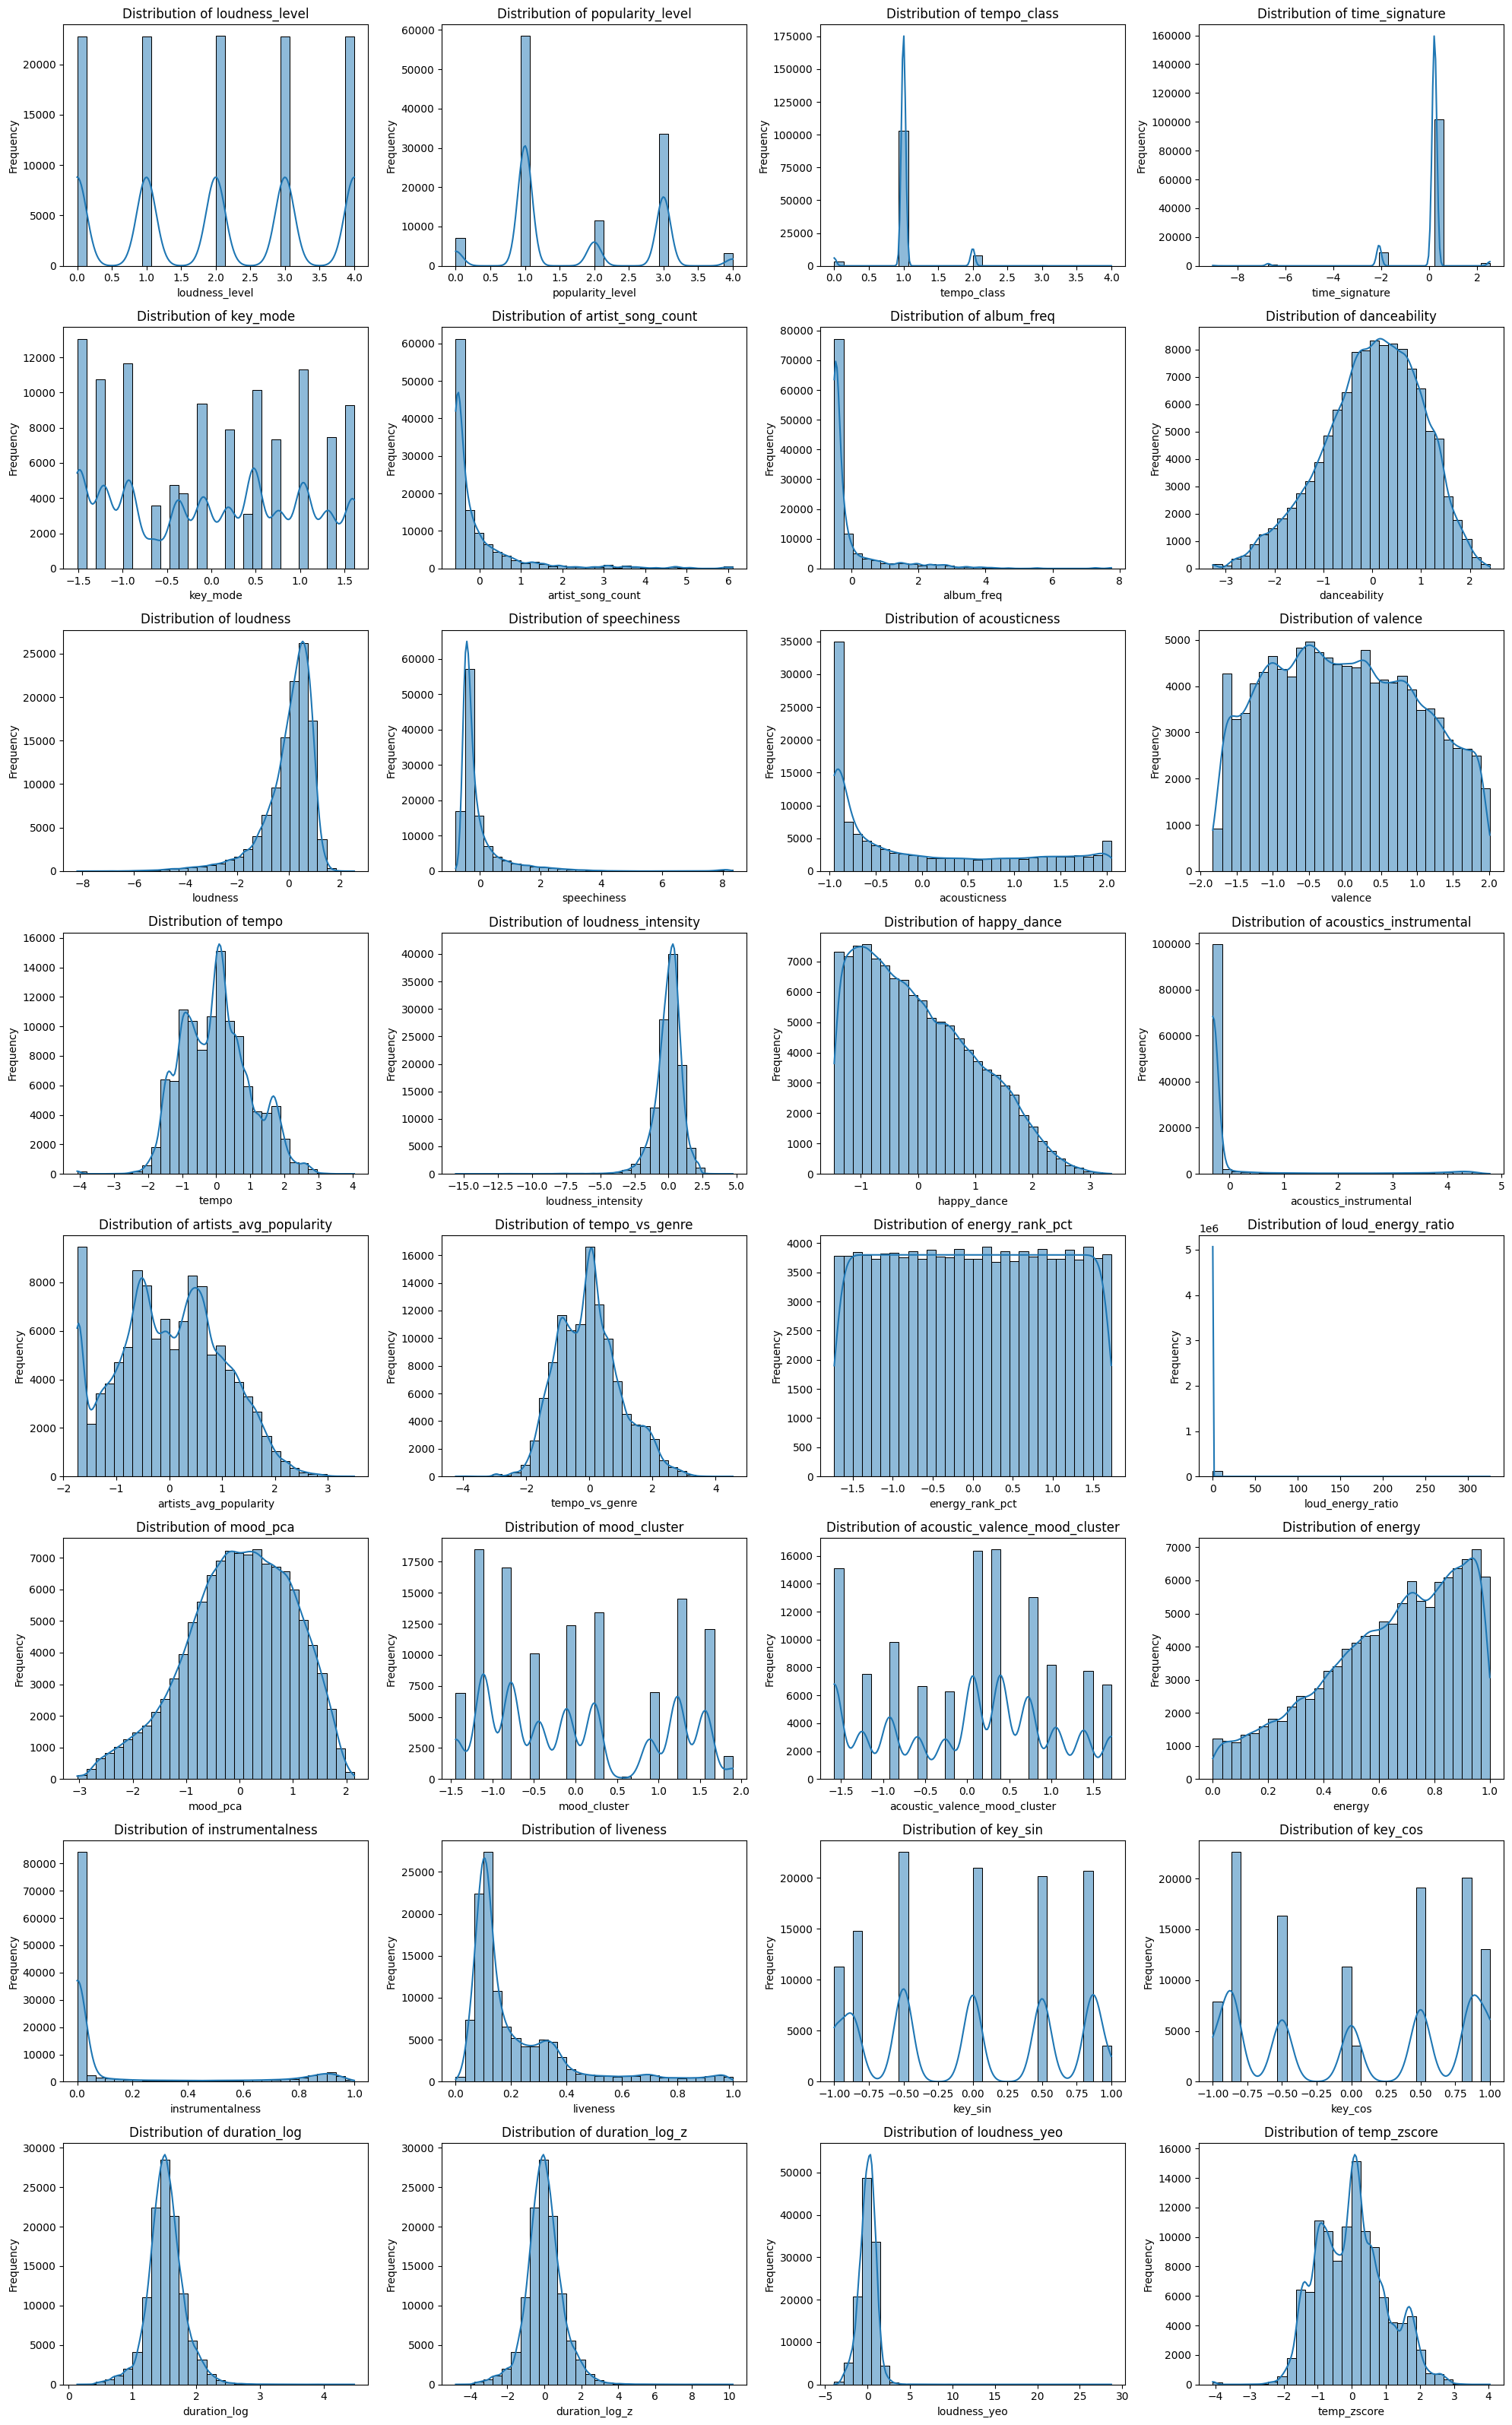

In [ ]:
if exAll:
    n_cols = 4
    n_rows = int(np.ceil(len(numeric_columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_columns):
        sns.histplot(data[col], bins=30, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

#### 1.3.2 Correlations

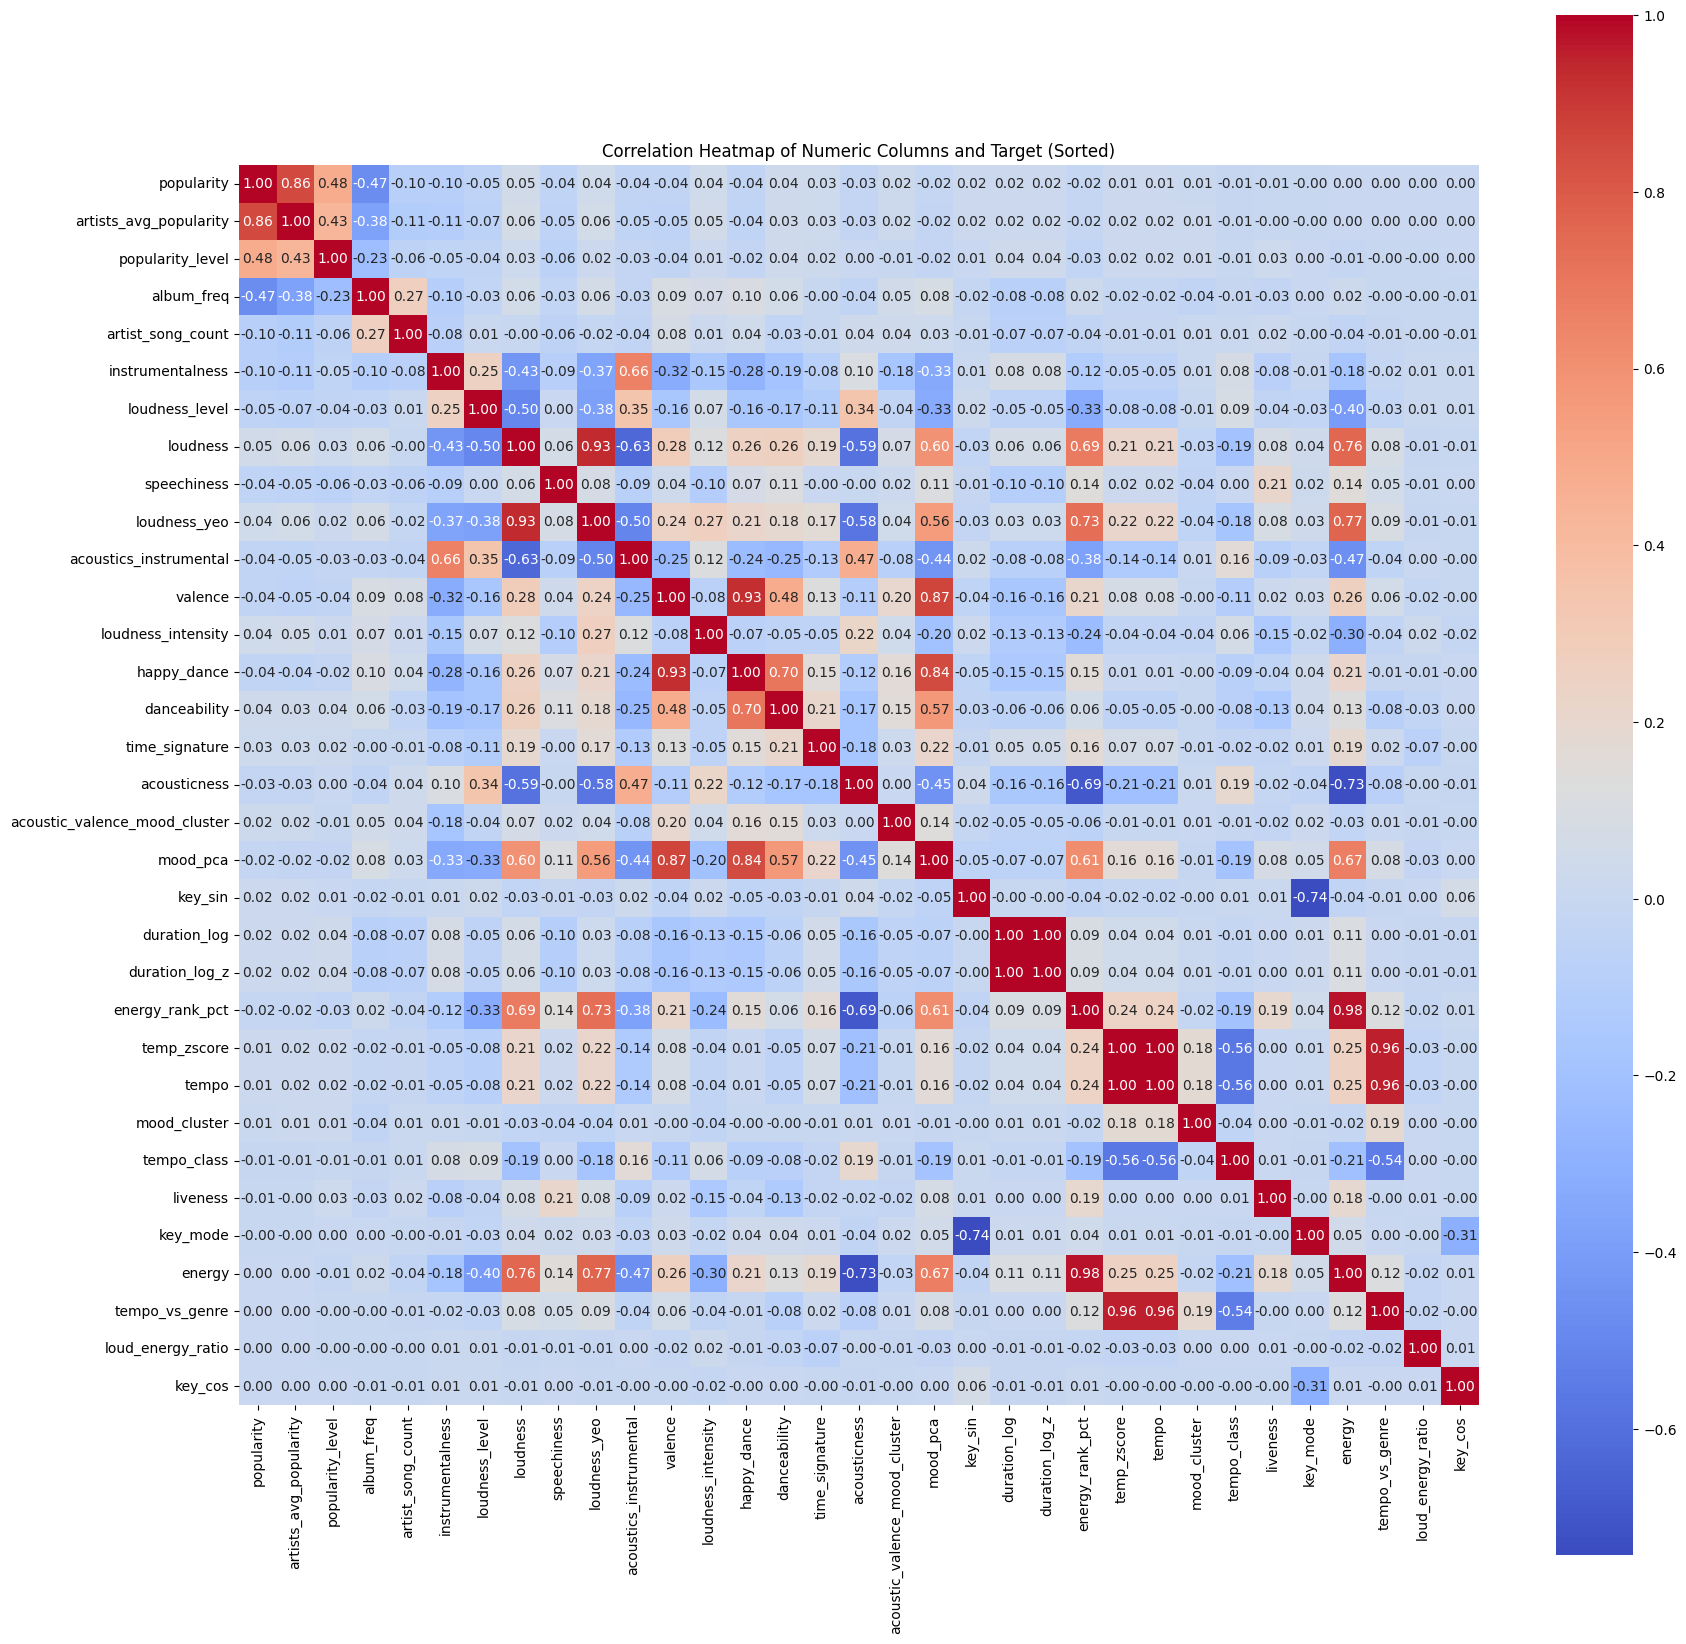

In [ ]:
if exAll:
    # Correlation heatmap of numeric columns and target
    plt.figure(figsize=(20, 20))
    corr = data[numeric_columns + [target]].corr()
    sorted_cols = corr[target].abs().sort_values(ascending=False).index
    corr_sorted = corr.loc[sorted_cols, sorted_cols]
    sns.heatmap(corr_sorted, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Heatmap of Numeric Columns and Target (Sorted)")
    plt.show()

In [8]:
#drop columns correlated with 1.0 with another column
to_drop = ["tempo", "duration_log"]
data.drop(columns=to_drop, inplace=True)

#### 1.3.3 Visualizations

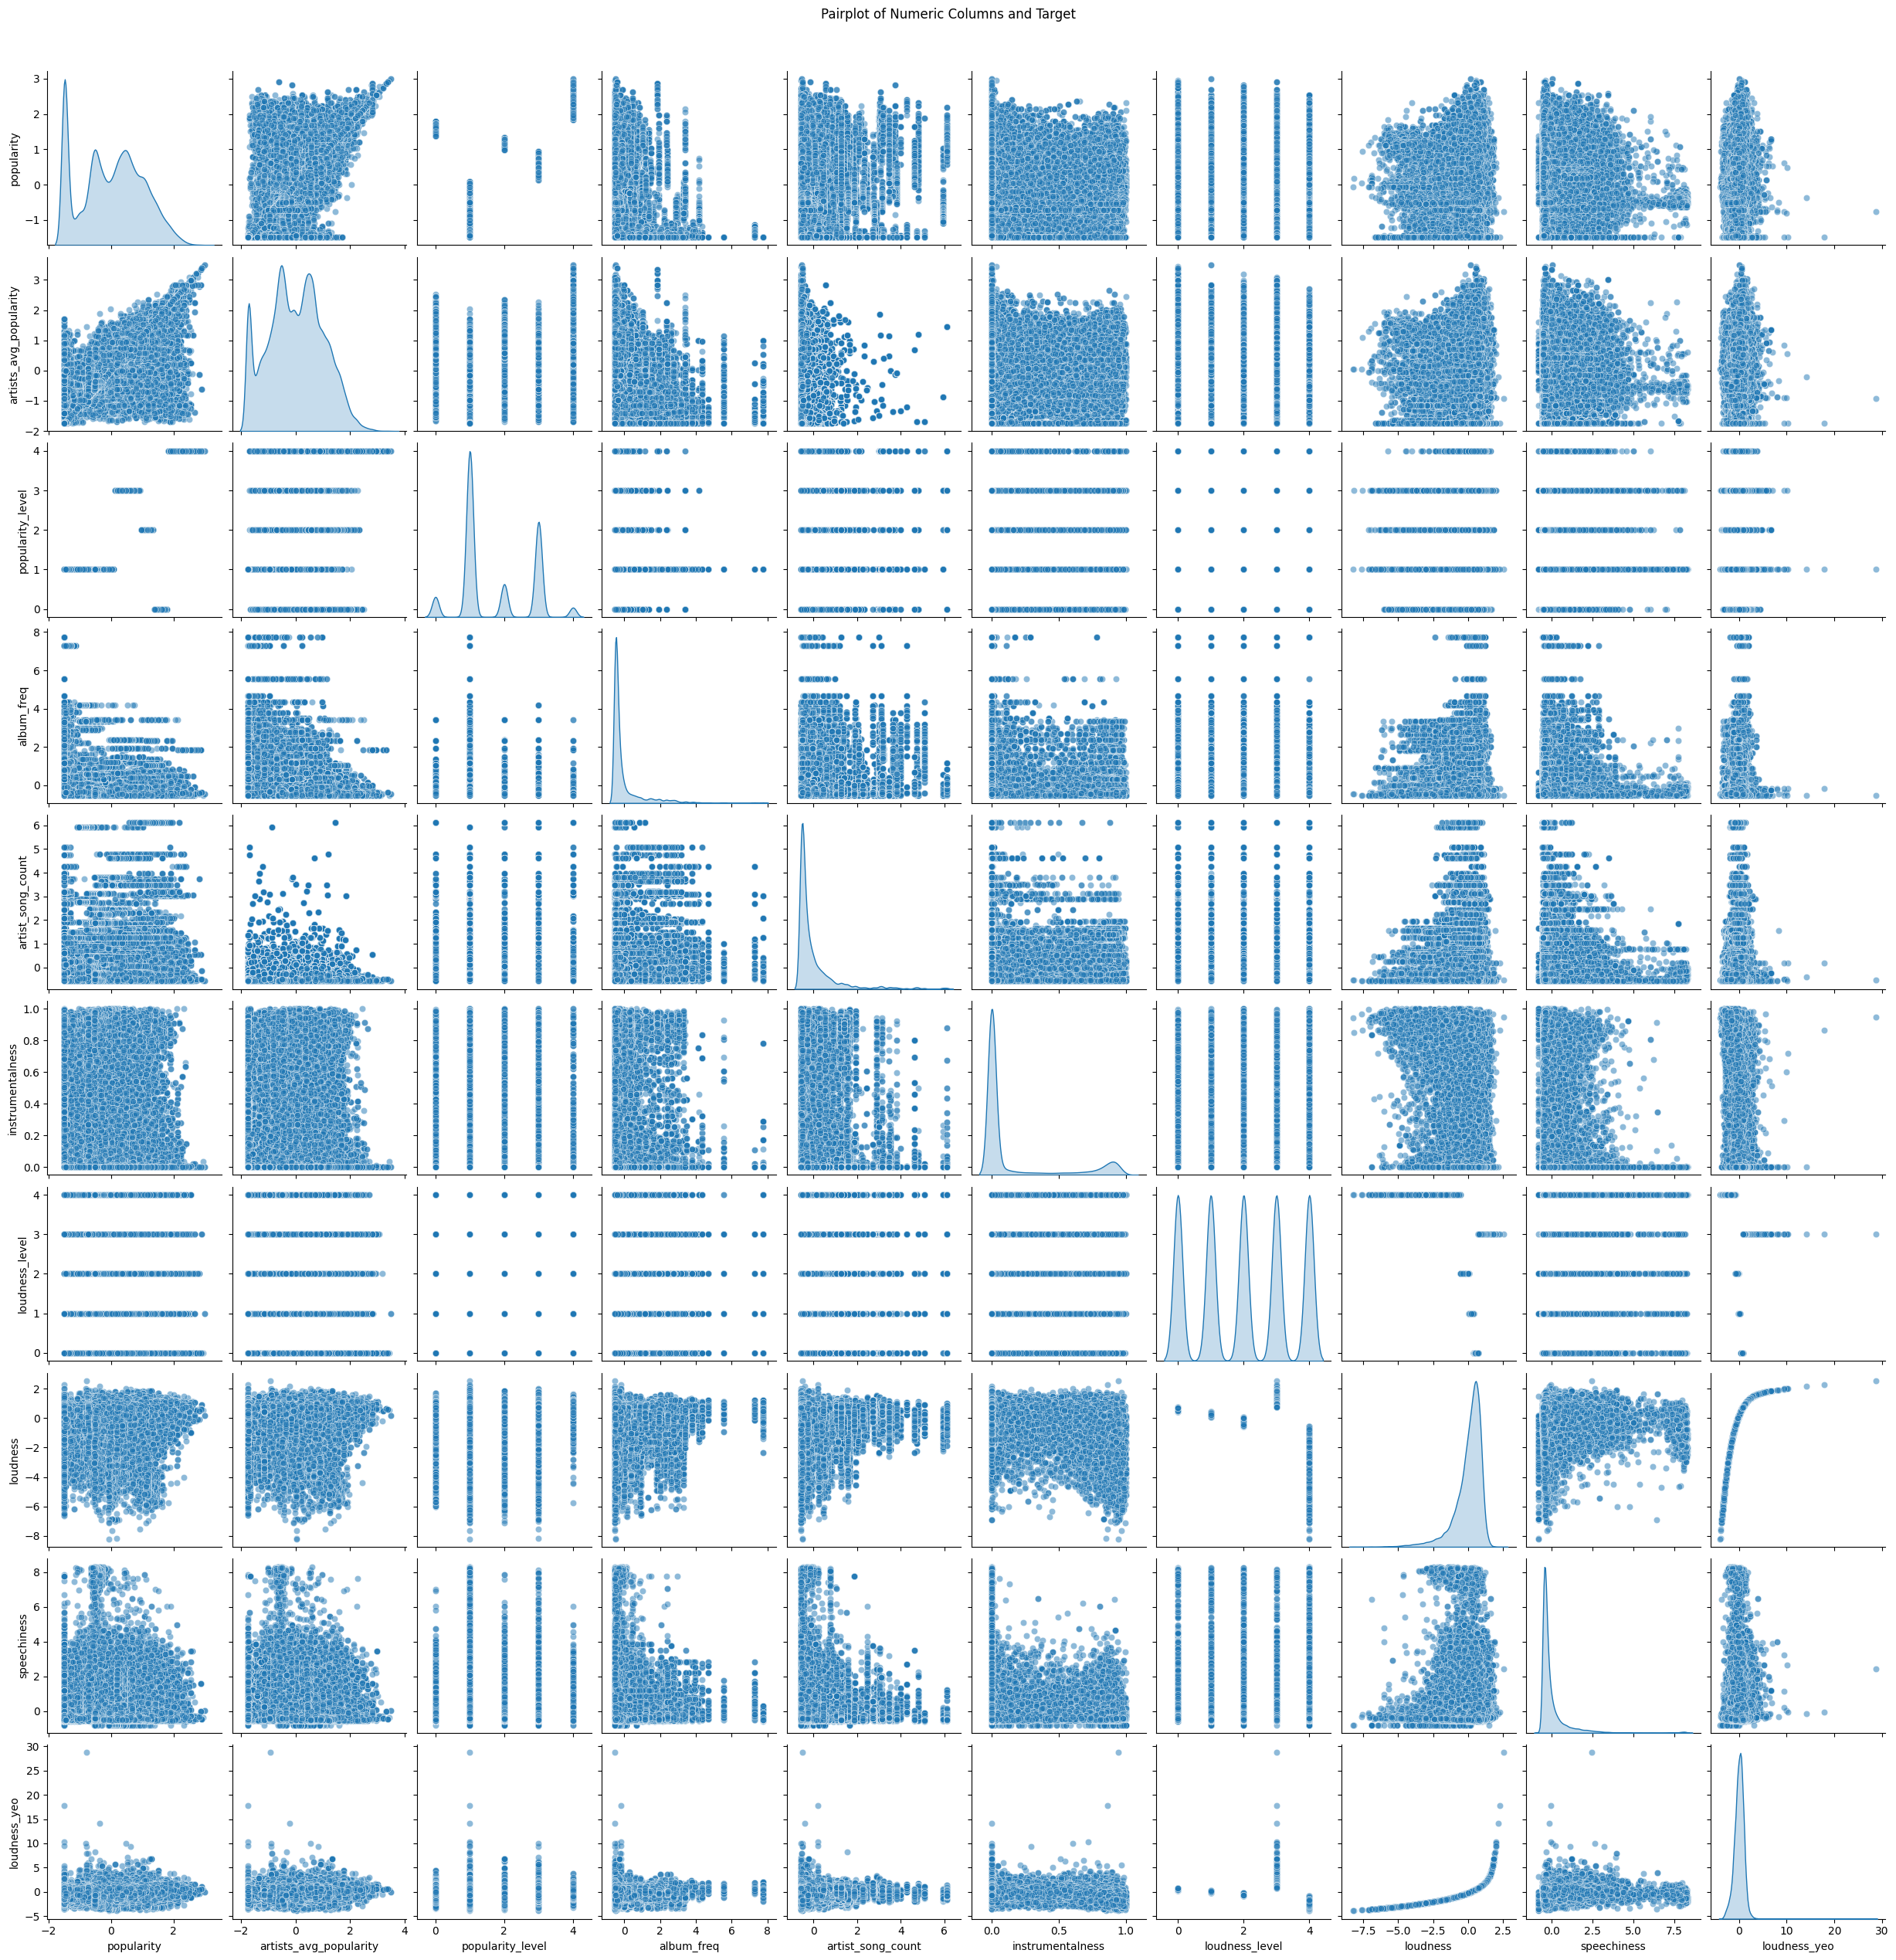

In [ ]:
# pairplots of 10 most correlated numeric columns and target (remove duplicates)
if exAll:
    to_plot = sorted_cols[:10].tolist() + [target]
    to_plot = list(dict.fromkeys(to_plot))  # removes duplicates, preserves order
    sns.pairplot(data[to_plot], diag_kind='kde', markers='o', plot_kws={'alpha': 0.5})
    plt.suptitle('Pairplot of Numeric Columns and Target', y=1.02)
    plt.show()


### 1.3.4 Target Variables

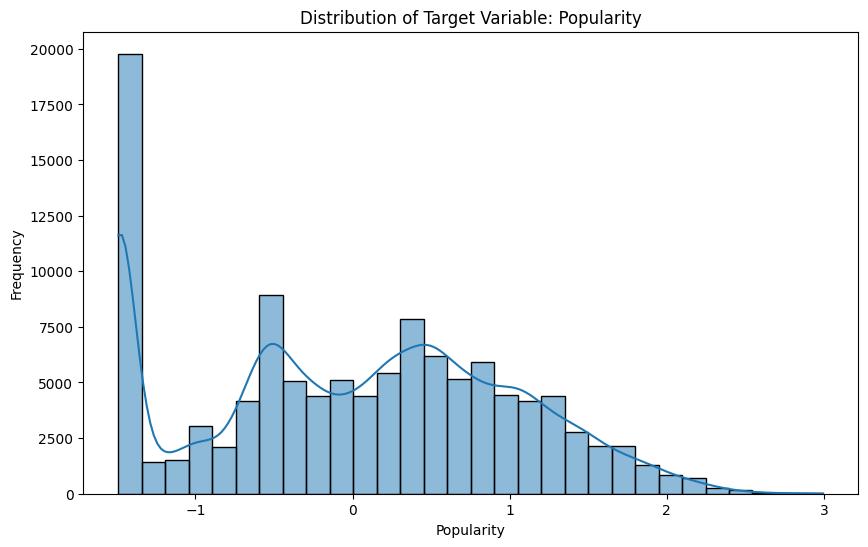

In [53]:
# target variable histogram

plt.figure(figsize=(10, 6))
sns.histplot(data[target], bins=30, kde=True)
plt.title('Distribution of Target Variable: Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_169210/1045411730.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[target], shade=True)


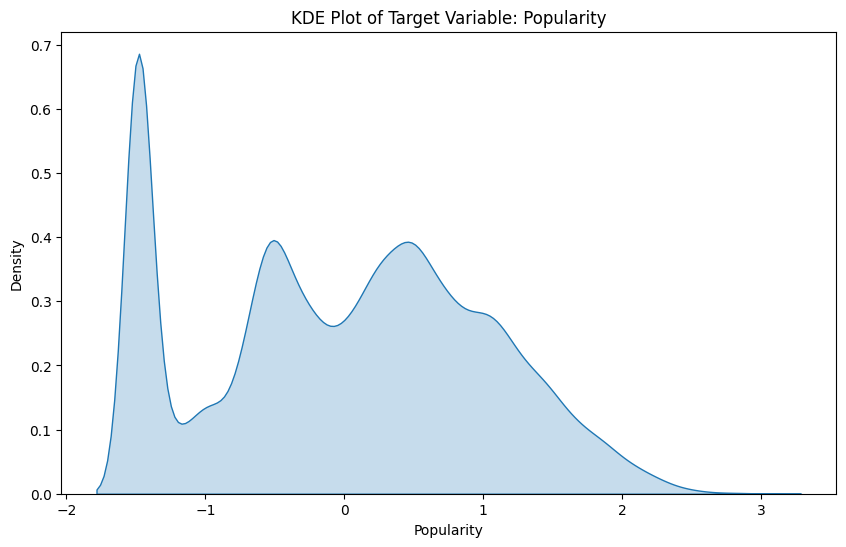

In [54]:
# target variable distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data[target], shade=True)
plt.title('KDE Plot of Target Variable: Popularity')
plt.xlabel('Popularity')
plt.ylabel('Density')
plt.show()

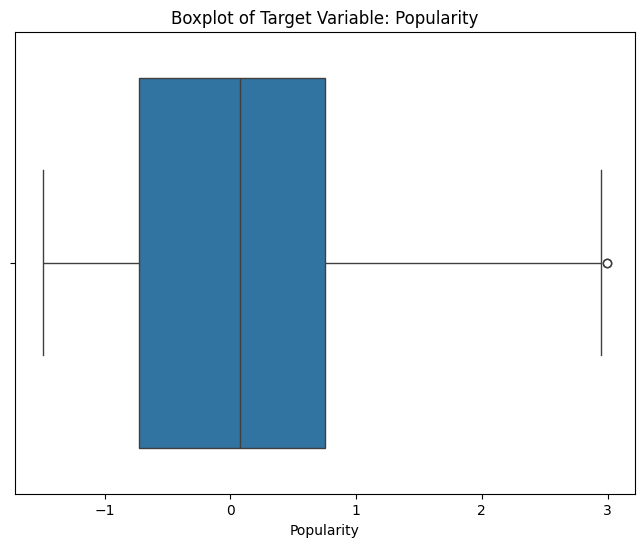

In [55]:
#target variabel boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=data[target])
plt.title('Boxplot of Target Variable: Popularity')
plt.xlabel('Popularity')
plt.show()

## 2 Data Cleaning and Preprocessing

### 2.1 Missing Values

There are no missing values. This dataset was mostly cleaned by the publisher

In [9]:
#has missing values?
data.isnull().sum().sum()

np.int64(0)

### 2.2 Duplicates

In [10]:
#drop duplicates and show new shape
data_clean = data.drop_duplicates()
print(f"Dropped {data.duplicated().sum()} duplicates: {data.shape} -> {data_clean.shape}")

Dropped 1133 duplicates: (113999, 155) -> (112866, 155)


### 2.3 Train/Test Split

In [11]:
def tt_split(data, target, test_size=0.2, random_state=42):
    X = data.drop(columns=[target])
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [12]:
print(f"Splitting the data with a test size of: {TEST_SIZE}")
X_train, X_test, y_train, y_test = tt_split(data_clean, target, test_size=TEST_SIZE, random_state=RANDOM_SEED)

Splitting the data with a test size of: 0.2
Train set: (90292, 154), Test set: (22574, 154)


### 2.4 Scaling and Encoding Pipelines

In [13]:
def build_preprocessor(numeric_cols, binary_cols, scaling=True):
    num_transformer = StandardScaler() if scaling else 'passthrough'
    # Combine pipelines into a ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_transformer, numeric_cols),
        ('bin', 'passthrough', binary_cols),
    ],
    remainder='drop')
    return preprocessor

### 2.5 Finalize dataset and columns

In [14]:
# drop columns that were dropped from the column lists
for col in numeric_columns:
    if col not in data_clean.columns:
        numeric_columns.remove(col)
for col in binary_columns:
    if col not in data_clean.columns:
        binary_columns.remove(col)
        
for col in one_hot_columns:
    if col not in data_clean.columns:
        one_hot_columns.remove(col)

## 3 Train and Evaluate Baseline Models (sklearn)

### 3.1 Define Model Pipelines

In [15]:
for model in BASELINE_MODELS.keys():
    print(BASELINE_MODELS[model])
print(PARAM_GRIDS)

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(n_jobs=-1, random_state=42)
SVR()
{'decision_tree': {'model__max_depth': [3, 5, 10, 20, 30, None], 'model__min_samples_split': [2, 5, 10, 20], 'model__min_samples_leaf': [1, 2, 4], 'model__criterion': ['squared_error']}, 'random_forest': {'model__n_estimators': [100, 500, 1000, 1500], 'model__max_depth': [5, 10, 50, None], 'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 2, 4], 'model__criterion': ['squared_error']}, 'svr': {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear']}}


### 3.2 Hyperparameter Grid Search

No Hyperparameter Tuning for Linear Regression only for tree and random forest.

In [46]:
import config
#reload config module
reload(config)
from config import *
best_parameters = {}

In [41]:
exAll = True

In [50]:
if exAll:
    model_name = "decision_tree"
    preprocessor = build_preprocessor(
        numeric_cols=numeric_columns,
        binary_cols=binary_columns + one_hot_columns,
        scaling=True,
    )
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", BASELINE_MODELS[model_name]),
    ])
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=RAND_DECISION_TREE,
        n_iter=300,
        cv=CV_FOLDS,
        n_jobs=8,
        scoring=SCORING_METRICS,
        refit="rmse",
        random_state=RANDOM_SEED,
        verbose=3,
    )
    rs.fit(X_train, y_train)
    best_parameters[model_name] = rs.best_params_

Fitting 3 folds for each of 300 candidates, totalling 900 fits
[CV 2/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__min_samples_split=22; mae: (test=-0.112) rmse: (test=-0.192) total time=   2.3s
[CV 3/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__min_samples_split=22; mae: (test=-0.112) rmse: (test=-0.192) total time=   2.4s
[CV 1/3] END model__criterion=squared_error, model__max_depth=44, model__min_samples_leaf=8, model__min_samples_split=22; mae: (test=-0.110) rmse: (test=-0.188) total time=   2.5s
[CV 3/3] END model__criterion=squared_error, model__max_depth=40, model__min_samples_leaf=4, model__min_samples_split=16; mae: (test=-0.110) rmse: (test=-0.193) total time=   2.6s
[CV 2/3] END model__criterion=squared_error, model__max_depth=40, model__min_samples_leaf=3, model__min_samples_split=24; mae: (test=-0.110) rmse: (test=-0.190) total time=   2.7s
[CV 1/3] END model__criterion=squared

In [56]:
best_parameters['decision_tree2'] = {'model__criterion': 'squared_error', 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 20}

In [ ]:
if exAll:
    model_name = "random_forest"
    preprocessor = build_preprocessor(
        numeric_cols=numeric_columns,
        binary_cols=binary_columns + one_hot_columns,
        scaling=True,
    )
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", BASELINE_MODELS[model_name]),
    ])
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=RAND_RANDOM_FOREST,
        n_iter=50,
        cv=CV_FOLDS,
        n_jobs=1,
        scoring=SCORING_METRICS,
        refit="rmse",
        random_state=RANDOM_SEED,
        verbose=3,
    )
    rs.fit(X_train, y_train)
    best_parameters[model_name] = rs.best_params_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV 1/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-0.185) rmse: (test=-0.263) total time=   5.1s
[CV 2/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-0.184) rmse: (test=-0.264) total time=   5.1s
[CV 3/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=40, model__max_features=sqrt, model__min_samples_leaf=8, model__min_samples_split=22, model__n_estimators=321; mae: (test=-0.184) rmse: (test=-0.262) total time=   5.1s
[CV 1/3] END model__bootstrap=True, model__criterion=squared_error, model__max_depth=20, model__max_features=None, model__min_samples_leaf=8, model__min_samples_split=22, model

Best parameters for random_forest: {'model__criterion': 'squared_error', 'model__max_depth': 50, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 1000}

In [59]:
best_parameters['random_forest2'] = {'model__criterion': 'squared_error', 'model__max_depth': 50, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 1000}

In [60]:
best_parameters

{'decision_tree': {'model__criterion': 'squared_error',
  'model__max_depth': 15,
  'model__min_samples_leaf': 5,
  'model__min_samples_split': 17},
 'decision_tree2': {'model__criterion': 'squared_error',
  'model__max_depth': 20,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 20},
 'random_forest2': {'model__criterion': 'squared_error',
  'model__max_depth': 50,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 2,
  'model__n_estimators': 1000}}

### 3.3 K-fold Cross-Validation Setup

In [52]:
#Train best models with best parameters found on k-fold crossvalidation datasets
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
linear_model = Pipeline([
    ("preprocessor", build_preprocessor(
        numeric_cols=numeric_columns,
        binary_cols=binary_columns + one_hot_columns,
        scaling=True,
    )),
    ("model", BASELINE_MODELS["linear"]),
])
linear_cv_results = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring=SCORING_METRICS,
    return_train_score=True,
    n_jobs=8,
)

# Decision Tree with best parameters
decision_tree_model = Pipeline([
    ("preprocessor", build_preprocessor(
        numeric_cols=numeric_columns,
        binary_cols=binary_columns + one_hot_columns,
        scaling=True,
    )),
    ("model", DecisionTreeRegressor(
        criterion=best_parameters['decision_tree']['model__criterion'],
        max_depth=best_parameters['decision_tree']['model__max_depth'],
        min_samples_leaf=best_parameters['decision_tree']['model__min_samples_leaf'],
        min_samples_split=best_parameters['decision_tree']['model__min_samples_split'],
        random_state=RANDOM_SEED,
    )),
])
decision_tree_cv_results = cross_validate(
    decision_tree_model,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring=SCORING_METRICS,
    return_train_score=True,
    n_jobs=8,
)

# Random Forest with best parameters
# random_forest_model = Pipeline([
#     ("preprocessor", build_preprocessor(
#         numeric_cols=numeric_columns,
#         binary_cols=binary_columns + one_hot_columns,
#         scaling=True,
#     )),
#     ("model", RandomForestRegressor(
#         criterion=best_parameters['random_forest']['model__criterion'],
#         max_depth=best_parameters['random_forest']['model__max_depth'],
#         min_samples_leaf=best_parameters['random_forest']['model__min_samples_leaf'],
#         min_samples_split=best_parameters['random_forest']['model__min_samples_split'],
#         n_estimators=best_parameters['random_forest']['model__n_estimators'],
#         max_features=best_parameters['random_forest'].get('model__max_features', None),
#         bootstrap=True,
#         random_state=RANDOM_SEED,
#         n_jobs=12,
#     )),
# ])
# random_forest_cv_results = cross_validate(
#     random_forest_model,
#     X_train,
#     y_train,
#     cv=CV_FOLDS,
#     scoring=SCORING_METRICS,
#     return_train_score=True,
#     n_jobs=1,
# )

# Collect results
cv_results = {
    "linear": linear_cv_results,
    "decision_tree": decision_tree_cv_results,
    # "random_forest": random_forest_cv_results,
}
for model_name, results in cv_results.items():
    print(f"\nModel: {model_name}")
    for metric in SCORING_METRICS.keys():
        train_score = np.mean(results[f'train_{metric}'])
        test_score = np.mean(results[f'test_{metric}'])
        print(f"  {metric}: Train = {train_score:.4f}, Test = {test_score:.4f}")


Model: linear
  rmse: Train = -0.4670, Test = -0.4682
  mae: Train = -0.2883, Test = -0.2890

Model: decision_tree
  rmse: Train = -0.1471, Test = -0.1827
  mae: Train = -0.0849, Test = -0.1049


### 3.4 Model Evaluation

In [ ]:
# train best models on full training set and evaluate on test set
final_results = {}
for model_name, model in [("linear", linear_model), ("decision_tree", decision_tree_model), ("random_forest", random_forest_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results = {}
    for metric_name, metric_func in SCORING_METRICS.items():
        if metric_name == "rmse":
            results[metric_name] = rmse(y_test, y_pred)
        elif metric_name == "mae":
            results[metric_name] = mae(y_test, y_pred)
    final_results[model_name] = results

## 4 Train and Evaluate Custom Implementations
### 4.1 Custom Regression Tree
### 4.2 Custom Random Forest
### 4.3 Comparison: sklearn vs Custom Implementations

## 5 Results and Discussion

### 5.1 Results Summary
### 5.2 Discussion and Insights